# 🚀 Making vLLM Fast

## One GPU. One model. Seven steps. Several times the speed.

---

You're going to take an ordinary `vllm serve` command and make it **dramatically faster** — without
touching a line of Python, and without buying a single extra GPU.

Along the way you'll be able to answer the question every team eventually asks:

> ### *"How many users can this thing actually serve?"*

**New to vLLM? You're in the right place.** Every step says what it does in plain English first.
The deeper details are tucked into fold-out boxes you can ignore.

---

### 🧗 The climb

We're building a ladder. **Every step adds one thing and the number goes up.**

| # | Step | What it does |
|---|---|---|
| 1️⃣ | **Get it running** | the API, tool calling, reasoning |
| 2️⃣ | **Turn up the users** | 1 → 16 → 128 → 512, and find the wall |
| 3️⃣ | **FP8 weights** | shrink the model |
| 4️⃣ | **FP8 KV cache** | shrink the notes it takes |
| 5️⃣ | **AITER expert kernels** | AMD's fast MoE code |
| 6️⃣ | **AITER everywhere** | ...and the rest |
| 7️⃣ | **Speculative decoding** | guess several words at once |

Plus two things we'll **look at but not score**, because a throughput number would mislead you:
**context sizing** (it's about capacity, not speed) and **prefix caching** (it depends on your traffic,
not your server).

Plus one **trap** we'll walk into deliberately, because the mistake is more memorable than the rule.

---

### 🎬 Our setup

|  |  |
|---|---|
| **Model** | `Qwen/Qwen3-30B-A3B` |
| **GPU** | 1× AMD Instinct MI300X (192 GB) |
| **Rule** | change one thing, measure, repeat |

Our model is a **Mixture-of-Experts**. It stores ~30 billion parameters but uses only about **3
billion per word** — like a hospital with 128 specialists where each patient sees 8 of them.

Hold onto that. It explains our most interesting result.

---
# 🧰 Setup

*Quick housekeeping. Already prepared? Skim and move on.*

In [1]:
!rocm-smi --showproductname 2>/dev/null | grep -E "Card Series|GFX Version" | head -4
!echo && echo "NUMA balancing (we want 0):" && cat /proc/sys/kernel/numa_balancing

GPU[0]		: Card Series: 		AMD Instinct MI355X
GPU[0]		: GFX Version: 		gfx950
GPU[1]		: Card Series: 		AMD Instinct MI355X
GPU[1]		: GFX Version: 		gfx950



NUMA balancing (we want 0):
0


> ⚠️ If that printed `1`, run `sudo sh -c 'echo 0 > /proc/sys/kernel/numa_balancing'`.
> Otherwise Linux shuffles memory around underneath the GPU and you get a hang that looks
> exactly like a vLLM bug.

### Get the container

We never install vLLM by hand. One image has ROCm, PyTorch and vLLM already built and version-matched
— which deletes an entire category of problem from your life.

In [2]:
%%bash
# Use a different image with:  export VLLM_IMAGE=...
IMAGE=${VLLM_IMAGE:-rocm/vllm:latest}
mkdir -p results logs
echo "image: $IMAGE"
docker image inspect "$IMAGE" >/dev/null 2>&1 && echo "already here ✓" || docker pull "$IMAGE"

image: vllm/vllm-openai-rocm:nightly-dc36fcce902a63eab06c1b93a5c4a5ee178a0c56


already here ✓


### 🩺 Health check — boring, and it will save your day

vLLM **renames flags between releases**. Worse: set an environment variable it no longer recognises
and vLLM says nothing at all. It just quietly ignores you.

You'd run your benchmark, get a number, and believe something false.

So we ask the image directly. Everything should say `OK`.

In [3]:
%%bash
IMAGE=${VLLM_IMAGE:-rocm/vllm:latest}
docker run --rm --entrypoint "" \
  --device /dev/kfd --device /dev/dri --group-add video --group-add render \
  "$IMAGE" bash -lc '
python3 -c "import vllm; print(\"vLLM version:\", vllm.__version__)"
echo
vllm serve --help=all 2>/dev/null > /tmp/h.txt
vllm bench serve --help=all 2>/dev/null > /tmp/b.txt
for f in --kv-cache-dtype --speculative-config --gpu-memory-utilization --cpu-offload-gb \
         --moe-backend --linear-backend --attention-backend --reasoning-parser; do
  grep -q -- "$f" /tmp/h.txt && echo "  OK       $f" || echo "  MISSING  $f"
done
for f in --num-warmups --tokenizer prefix_repetition; do
  grep -q -- "$f" /tmp/b.txt && echo "  OK       $f" || echo "  MISSING  $f"
done
'

vLLM version: 0.29.1rc1.dev47+gdc36fcce9


  OK       --kv-cache-dtype


  OK       --speculative-config


  OK       --gpu-memory-utilization


  OK       --cpu-offload-gb


...

  OK       --attention-backend


  OK       --reasoning-parser


  OK       --num-warmups


  OK       --tokenizer


  OK       prefix_repetition


<details>
<summary>🔧 <b>If anything says MISSING</b></summary>

- **`--moe-backend` / `--linear-backend` / `--attention-backend`** — your image is older. It picks
  kernels with environment variables instead (`VLLM_ROCM_USE_AITER_MOE`, `VLLM_ROCM_USE_AITER_MHA`,
  `VLLM_USE_TRITON_FLASH_ATTN`). Use those in the AITER section and check the log to confirm they took effect.
- **`--num-warmups`** — drop the flag and run each benchmark twice, ignoring the first.
- `vllm serve --help` needs GPU devices attached, which is why this cell passes `--device` even though
  it never starts a server.

</details>

### Download the weights

~92 GB. **Do this before the audience arrives.** Cached already? Returns in seconds.

In [4]:
%%bash
IMAGE=${VLLM_IMAGE:-rocm/vllm:latest}
docker run --rm -v ~/.cache/huggingface:/root/.cache/huggingface \
    --entrypoint python3 "$IMAGE" -c \
    "from huggingface_hub import snapshot_download as d; \
     d('Qwen/Qwen3-30B-A3B'); d('Qwen/Qwen3-30B-A3B-FP8')" 2>&1 | tail -1
du -sh ~/.cache/huggingface/hub 2>/dev/null

Fetching 17 files: 100%|█████

█████| 17/17 [00:00<00:00, 2511.56it/s]


88G	/home/asirra/.cache/huggingface/hub


---
## 🐳 The one command we reuse all day

Every server below is the **same `docker run`** with different `vllm serve` flags on the end:

```bash
docker run -d --rm --name vllm-server \
    --network host --ipc host \
    --device /dev/kfd --device /dev/dri \
    --group-add video --group-add render \
    --shm-size 16g  -e HIP_VISIBLE_DEVICES=0 \
    -v ~/.cache/huggingface:/root/.cache/huggingface \
    -v $PWD/results:/results \
    --entrypoint '' \
    rocm/vllm:latest \
    vllm serve Qwen/Qwen3-30B-A3B --served-model-name qwen --port 8000
```

<details>
<summary>🐳 <b>What each Docker flag is for</b></summary>

| Flag | Why |
|---|---|
| `--device /dev/kfd --device /dev/dri` | the AMD GPU driver. Without these there's no GPU in the container |
| `--group-add video --group-add render` | permission to open those devices |
| `--ipc host --shm-size 16g` | shared memory for PyTorch. Too small → mystery hangs |
| `--network host` | `localhost:8000` means the same inside and out |
| `-v ~/.cache/huggingface` | weights download **once**, shared by every run |
| `-v $PWD/results:/results` | benchmark files land in your folder |
| `-d` | detached, so the notebook keeps going |
| `-e HIP_VISIBLE_DEVICES=0` | GPU 0 only — essential on a shared box |
| `--entrypoint ''` | some images pre-set `ENTRYPOINT ["vllm","serve"]`; clearing it lets us write the command out in full |

**`--served-model-name qwen`** is a nice trick: later we swap to a different checkpoint with a
different Hugging Face name. Pinning the served name to `qwen` keeps **every other command in this
notebook identical**.

</details>

In [5]:
import os
DOCKER = "docker run -d --rm --name vllm-server " \
         "--network host --ipc host " \
         "--device /dev/kfd --device /dev/dri " \
         "--group-add video --group-add render " \
         "--shm-size 16g -e HIP_VISIBLE_DEVICES=0 " \
         "-v ~/.cache/huggingface:/root/.cache/huggingface " \
         "-v $PWD/results:/results " \
         "--entrypoint ''"

IMAGE = os.environ.get("VLLM_IMAGE", "rocm/vllm:latest")
print("ready · image:", IMAGE)

ready · image: vllm/vllm-openai-rocm:nightly-dc36fcce902a63eab06c1b93a5c4a5ee178a0c56


### Two small helpers

**`wait.sh`** holds the notebook until the server actually answers, so nothing fires too early.

**`scoreboard()`** is our ladder. We call it after every step and watch the number climb. 📈

In [6]:
%%writefile wait.sh
#!/bin/bash
echo "starting server — this takes a few minutes..."
for i in $(seq 1 300); do
    curl -sf localhost:8000/health > /dev/null && { echo "✅ ready in $((i*2))s"; exit 0; }
    docker ps -q -f name=^vllm-server$ | grep -q . || {
        echo "❌ container died:"; docker logs --tail 30 vllm-server; exit 1; }
    sleep 2
done
echo "❌ not up after 10 min:"; docker logs --tail 30 vllm-server

Writing wait.sh


In [7]:
import json, glob

def scoreboard():
    rows = []
    for f in sorted(glob.glob("results/*.json")):
        d = json.load(open(f))
        rows.append((f.split("/")[-1][:-5].split("-", 1)[1],
                     d["total_token_throughput"], d["median_ttft_ms"], d["median_tpot_ms"]))
    if not rows:
        print("no results yet"); return rows
    top = max(r[1] for r in rows)
    # everything after the concurrency ramp is compared to the 128-user baseline
    base = next((r[1] for r in rows if r[0].startswith("512users")), rows[0][1])
    print(f"{'STEP':<16}{'TOTAL TOK/S':>13}  {'':<26}{'vs 512-user':>12}{'TPOT ms':>10}")
    print("─" * 80)
    for name, t, _, tpot in rows:
        bar = "█" * max(1, round(24 * t / top))
        print(f"{name:<16}{t:>13,.0f}  {bar:<26}{t/base:>11.2f}x{tpot:>10,.1f}")
    return rows

print("helpers loaded ✓")

helpers loaded ✓


---
---
# 1️⃣ First light — get it running

### 🎯 Goal
A working LLM API, and a look at what it can do.

This is the plainest possible command. No tuning. What everyone types on day one.

We do pass three extras, but they're **free** — they change how answers are *formatted*, not how fast
they arrive:

| Flag | What it gives you |
|---|---|
| `--enable-auto-tool-choice` | the model can call your functions |
| `--tool-call-parser hermes` | those calls arrive as clean JSON |
| `--reasoning-parser qwen3` | the model's "thinking" arrives in its own field |

> 📌 **Feature flags vs performance flags.** These three are feature flags — they never move a
> benchmark number. Everything else we add today is a performance flag. Keeping those apart in your
> head is genuinely useful.

In [8]:
!{DOCKER} {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3

a9fd5fab51c77eb18efe823ea13e3b95874cf5281eccd0a1abad846f9c699a55


In [9]:
!bash wait.sh

starting server — this takes a few minutes...


✅ ready in 102s


## 💬 Say hello

vLLM speaks the **OpenAI API**. Anything that already talks to OpenAI talks to this by changing one
URL. No rewrite.

It's plain HTTP — here it is with nothing but `curl`:

In [10]:
%%bash
curl -s localhost:8000/v1/chat/completions -H "Content-Type: application/json" \
  -d '{"model":"qwen","messages":[{"role":"user","content":"Say hello in one short sentence."}],"max_tokens":40,"chat_template_kwargs":{"enable_thinking":false}}' \
| head -c 400

{"id":"chatcmpl-8e38d83e1f55d399","object":"chat.completion","created":1789627407,"model":"qwen","ch

oices":[{"index":0,"message":{"role":"assistant","content":"Hello!","refusal":null,"annotations":nul

l,"audio":null,"function_call":null,"reasoning":null},"logprobs":null,"finish_reason":"stop","stop_r

eason":null,"token_ids":null,"routed_experts":null}],"service_tier":null,"system_fingerprint":"vllm-

That works, but reading raw JSON gets old fast. **Let's write one small helper and use it for the rest
of the notebook.**

It does exactly what the `curl` above does — sends a question, reads the reply — and prints the three
things we care about: the **thinking**, any **tool call**, and the **answer**.

> ⚠️ **Qwen3 quirk, worth knowing immediately:** this model *thinks before answering* by default. Ask
> it something trivial and your whole token budget vanishes into thinking, leaving an empty answer.
> So our helper defaults thinking **off**, and we switch it on when we actually want it.

In [11]:
import json, urllib.request

def ask(question, tools=None, think=False, max_tokens=400):
    '''Send a question to our vLLM server and print the interesting parts.'''
    body = {
        "model": "qwen",
        "messages": [{"role": "user", "content": question}],
        "max_tokens": max_tokens,
        "temperature": 0,
        "chat_template_kwargs": {"enable_thinking": think},
    }
    if tools:
        body["tools"], body["tool_choice"] = tools, "auto"

    req = urllib.request.Request(
        "http://localhost:8000/v1/chat/completions",
        data=json.dumps(body).encode(),
        headers={"Content-Type": "application/json"})
    reply = json.loads(urllib.request.urlopen(req, timeout=300).read())
    msg = reply["choices"][0]["message"]

    # vLLM renamed this field across versions — accept either
    thinking = msg.get("reasoning_content") or msg.get("reasoning")
    if thinking:
        print("🧠 THINKING:", " ".join(thinking.split())[:300], "...\n")
    for call in (msg.get("tool_calls") or []):
        print("🔧 TOOL CALL:", call["function"]["name"])
        print("   ARGUMENTS:", call["function"]["arguments"], "\n")
    if msg.get("content"):
        print("💬 ANSWER:", " ".join(msg["content"].split())[:400])
    return msg

print("helper ready — try  ask('your question')")

helper ready — try  ask('your question')


In [12]:
ask("What is the capital of India?")

💬 ANSWER: The capital of India is **New Delhi**. It is the seat of the Government of India and houses important institutions such as the Parliament of India, the Rashtrapati Bhavan (Presidential Palace), and the Supreme Court.


{'role': 'assistant',
 'content': 'The capital of India is **New Delhi**. It is the seat of the Government of India and houses important institutions such as the Parliament of India, the Rashtrapati Bhavan (Presidential Palace), and the Supreme Court.',
 'refusal': None,
 'annotations': None,
 'audio': None,
 'function_call': None,
 'reasoning': None}

## 🔧 Tool calling

**You describe a function. The model decides to call it and fills in the arguments.**

This is how a model reaches a weather API, a database, or any code you own. It never runs anything
itself — it just says *what* to call and *with what*. Your app does the rest.

In [13]:
WEATHER_TOOL = [{
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get the current weather for a city.",
        "parameters": {
            "type": "object",
            "properties": {
                "city": {"type": "string"},
                "unit": {"type": "string", "enum": ["celsius", "fahrenheit"]},
            },
            "required": ["city"],
        },
    },
}]

ask("What is the weather in Bengaluru today?", tools=WEATHER_TOOL)

🔧 TOOL CALL: get_weather
   ARGUMENTS: {"city": "Bengaluru"} 



{'role': 'assistant',
 'content': None,
 'refusal': None,
 'annotations': None,
 'audio': None,
 'function_call': None,
 'tool_calls': [{'id': 'chatcmpl-tool-9ff245897e03b362',
   'type': 'function',
   'function': {'name': 'get_weather', 'arguments': '{"city": "Bengaluru"}'}}],
 'reasoning': None}

Notice it worked out `city` by itself from *"in Bengaluru"*. Your app would now call the real weather
service and hand the result back to the model.

## 🧠 Thinking, kept separate

**Qwen3 can reason step by step before answering.** The reasoning parser puts that in its own field —
so you can log it, hide it, or bill for it, without it leaking into what the user reads.

Same helper, one extra argument: `think=True`.

In [14]:
ask("I have 3 boxes with 7 apples in each. I give away 5 apples. How many are left?",
    think=True, max_tokens=1200)

🧠 THINKING: Okay, let's see. The problem says I have 3 boxes with 7 apples each. So first, I need to figure out how many apples I have in total. If each box has 7 apples and there are 3 boxes, I should multiply 3 by 7. Let me do that: 3 times 7 is 21. So, 21 apples in total. Then, I give away 5 apples. To find  ...

💬 ANSWER: You start with 3 boxes, each containing 7 apples. **Total apples initially:** $ 3 \times 7 = 21 $ apples. **After giving away 5 apples:** $ 21 - 5 = 16 $ apples. **Answer:** $\boxed{16}$


{'role': 'assistant',
 'content': '\n\nYou start with 3 boxes, each containing 7 apples. \n\n**Total apples initially:**  \n$ 3 \\times 7 = 21 $ apples.\n\n**After giving away 5 apples:**  \n$ 21 - 5 = 16 $ apples.\n\n**Answer:** $\\boxed{16}$',
 'refusal': None,
 'annotations': None,
 'audio': None,
 'function_call': None,
 'reasoning': "\nOkay, let's see. The problem says I have 3 boxes with 7 apples each. So first, I need to figure out how many apples I have in total. If each box has 7 apples and there are 3 boxes, I should multiply 3 by 7. Let me do that: 3 times 7 is 21. So, 21 apples in total.\n\nThen, I give away 5 apples. To find out how many are left, I need to subtract the 5 apples I gave away from the total. So, 21 minus 5. Let me calculate that. 21 minus 5 is 16. Hmm, that seems straightforward. Wait, is there any chance I might have misread the problem? Let me check again.\n\nThe question says 3 boxes with 7 apples each. So 3*7=21. Then giving away 5 apples. So 21-5=16. Ye

> ✅ **You now have a working, tool-calling, reasoning LLM server.**
> Time to find out how fast it is — and what's holding it back.

---
---
# 2️⃣ The most important lesson 🔑

### 🎯 Goal
Understand the one idea everything else depends on.

---

## One user barely touches your GPU

Here's the surprise: send **one** request to this enormous GPU and most of it sits idle.

Writing text is sequential — word 2 can't start until word 1 is done. Each word needs a full sweep
over the model's memory, and **fetching that memory takes far longer than the math**. With one user,
your GPU spends its life waiting, not computing.

### 🍳 The kitchen analogy

A chef fetches every ingredient from the walk-in freezer to make **one** omelette. The walk-in trip
dominates. Making **fifty** omelettes? Same trip, fifty omelettes. Barely slower.

vLLM does this automatically — **continuous batching** — and it reshuffles the batch every single
step, so finished requests leave and new ones join mid-flight.

Let's prove it. Same server, nothing restarted. We just change how many requests are in flight.

> **Three numbers:**
> 🟢 **Throughput** (tokens/sec) — total work. Higher is better.
> 🔴 **TTFT** (ms) — wait before the first word appears. Lower is better.
> 🔴 **TPOT** (ms) — time per word after that. Lower is better.

Each request is substantial — a ~4,000-token prompt and a ~1,000-token answer, which is what a RAG or
document-QA app really looks like. That size matters: it's what puts genuine pressure on GPU memory
later on.

> 📊 **We measure *total* tokens/sec** — prompt tokens read **plus** answer tokens written. That's the
> real work the GPU did. Output-only numbers flatter workloads with short prompts.

### 🤔 Guess first
Going from 1 user to 512 — does total throughput go up **2×? 10×? 50×?**
And does it keep climbing all the way, or stop somewhere?

In [15]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 4 --max-concurrency 1 --num-warmups 1 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 01-1user.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         227.48    
Median TTFT (ms):                        81.33     
Median TPOT (ms):                        4.33      


In [16]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 32 --max-concurrency 16 --num-warmups 4 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 02-16users.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         1438.78   
Median TTFT (ms):                        1080.22   
Median TPOT (ms):                        10.03     


In [17]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 128 --max-concurrency 128 --num-warmups 8 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 03-128users.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         3584.84   
Median TTFT (ms):                        4940.53   
Median TPOT (ms):                        30.70     


In [18]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 04-512users.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         4735.67   
Median TTFT (ms):                        10743.27  
Median TPOT (ms):                        84.37     


In [19]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                   1,137  █                                0.05x       4.3
16users                 7,194  ███████                          0.30x      10.0
128users               17,924  ██████████████████               0.76x      30.7
512users               23,678  ████████████████████████         1.00x      84.4


## 📊 What that just told you

**1. Throughput explodes.** Not 2×. Serving 128 users costs *far* less than 128× the time.
That's batching earning its keep — and it's why **benchmarking with one request tells you nothing
about production.**

**2. TTFT gets worse.** More people queuing means everyone waits a little longer for their first word.

> ### ⚖️ The trade-off you can never escape
> **Throughput and latency pull against each other.** No setting maximises both.
> Tuning is choosing *where on that curve you want to sit.*
> A nightly batch job wants the right end. A chatbot wants the left.

**3. It stops climbing.** Look at the last two rows — going from 128 to 320 users buys far less than
128 did. *Something* put a ceiling on it. That ceiling is the whole rest of this notebook.

---

## 🔑 What stops it: the KV cache

Here's the idea the rest of this notebook rests on.

**As the model writes, it keeps notes on every word so far — for every user — in GPU memory.**
Without those notes it would re-read the whole conversation to produce each new word.

Those notes are the **KV cache**, and they are *big*.

So your GPU memory splits up like this:

```
  ┌────────────────────────────────────────────────┐
  │  MODEL WEIGHTS      fixed — the model itself   │
  ├────────────────────────────────────────────────┤
  │  working memory     small, temporary           │
  ├────────────────────────────────────────────────┤
  │                                                │
  │   🧠  KV CACHE POOL   ← everything left over   │
  │                                                │
  │       THIS IS YOUR USER LIMIT                  │
  │                                                │
  └────────────────────────────────────────────────┘
```

Every simultaneous user rents a slice of that pool. **Run out, and new requests wait in line — no
matter how bored the compute is.**

> ## 🎯 So the whole game is:
> # Make the pool bigger.
> Bigger pool → more simultaneous users → further up the throughput curve.

---

## vLLM already told you the answer

It prints this at startup. Almost nobody reads it.

In [20]:
!docker logs vllm-server 2>&1 \
  | grep -iE "Model loading took|Available KV cache memory|GPU KV cache size" | cut -c1-165

(EngineCore pid=602) INFO 09-17 06:42:41 [model_runner.py:431] Model loading took 56.88 GiB memory and 18.949818 seconds
(EngineCore pid=602) INFO 09-17 06:43:09 [gpu_worker.py:638] Available KV cache memory: 198.38 GiB
(EngineCore pid=602) INFO 09-17 06:43:09 [kv_cache_utils.py:2370] GPU KV cache size: 2,166,864 tokens, Maximum concurrency for 40,960 tokens per request: 52.90x


| Line | Meaning |
|---|---|
| `Model loading took … GiB` | what the **weights** ate |
| `Available KV cache memory` | what was **left over** for the pool |
| `GPU KV cache size: … tokens` | the pool, in words, across **all users at once** |
| `Maximum concurrency … NN.NNx` | ⭐ **vLLM doing the division for you** |

**That last number is the headline.** It says *"I can hold about NN requests at once."*

If it reads `50x` and you planned for 500 users — congratulations, you just learned that **without
writing a load test.**

### 🧮 Now do the arithmetic yourself

Our requests are ~8,300 tokens each. Take the `GPU KV cache size` from above and divide:

```
    2,166,864 tokens  ÷  5,120 tokens per request  ≈  423 users
```

**We just asked for 512.** Around 90 of them had nowhere to sit and had to wait — which is exactly
why that last jump disappointed.

> ## 🎯 That number — 423 — is our enemy for the rest of the notebook.
> Every step from here makes the pool bigger or each user cheaper, so more of those 512 fit.
> Watch it climb. 👇

---
---
# 📐 Interlude — context length and the KV pool

*We look at this one. We don't score it. Here's why — and it's the most useful surprise in the
notebook.*

### 🎯 Goal
Understand what `--max-model-len` actually does, because almost everyone (including the first draft of
this notebook) gets it wrong.

### The claim you'll hear

> *"Lower `--max-model-len` and you free up KV cache."*

**It isn't true.** Watch the pool size before and after.

Along with three companions:

| Flag | Plain English |
|---|---|
| `--max-num-seqs 256` | batch at most this many requests |
| `--max-num-batched-tokens 8192` | work budget per step |
| `--gpu-memory-utilization 0.92` | you may use 92% of the card |

<details>
<summary>📐 <b>How to pick these for your own workload</b></summary>

- **`--max-model-len`** — your real worst-case prompt + answer. Look at your p99, not the model card.
- **`--max-num-batched-tokens`** is the TTFT ↔ smoothness dial. A **big** budget chews through new
  prompts fast but stutters the text streaming to everyone already connected. A **small** one does the
  reverse. This is the knob for "why is output choppy?"
- **`--gpu-memory-utilization`** — people treat it as a safety margin. It's really a performance
  setting: every percent unused is KV cache you don't get.
- **`--max-num-seqs`** only helps if clients actually send that many at once.

</details>

### 👀 Watch the pool, then read what happened

In [21]:
!docker logs vllm-server > logs/baseline.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [22]:
!{DOCKER} {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92

941e2f5e6d6ada0865a53b0872373e3ce71216670961b894ca23b8374a231974


In [23]:
!bash wait.sh

starting server — this takes a few minutes...


✅ ready in 102s


In [24]:
%%bash
echo "════ BEFORE — default 40,960-token context ════"
grep -iE "GPU KV cache size" logs/baseline.log | cut -c1-165 | head -1
echo
echo "════ AFTER — sized to 8,192 ════"
docker logs vllm-server 2>&1 | grep -iE "GPU KV cache size" | cut -c1-165 | head -1

════ BEFORE — default 40,960-token context ════


(EngineCore pid=602) INFO 09-17 06:43:09 [kv_cache_utils.py:2370] GPU KV cache size: 2,166,864 token

s, Maximum concurrency for 40,960 tokens per request: 52.90x



════ AFTER — sized to 8,192 ════


(EngineCore pid=602) INFO 09-17 06:49:17 [kv_cache_utils.py:2370] GPU KV cache size: 2,188,896 token

s, Maximum concurrency for 8,192 tokens per request: 267.20x


### 🤯 The pool did not change

Look carefully: **`GPU KV cache size` is the same both times.** The memory was never the thing
`--max-model-len` controls.

What *did* change is the `Maximum concurrency` figure — because vLLM computes it as:

```
   Maximum concurrency  =  KV pool ÷ max-model-len
                           ↑ same     ↑ we shrank this
```

We changed the **denominator**, not the pool. So what is this flag actually for?

| What `--max-model-len` really does | Why you care |
|---|---|
| Caps how long any single conversation may get | stops one giant request eating the whole pool |
| Sets the worst-case reservation per request | lets the scheduler admit more requests confidently |
| Shrinks per-request scheduling overhead | **improves TTFT**, which you'll see below |

> ### 📌 The honest rule
> **`--max-model-len` buys you predictability and latency, not throughput.**
> If you want a *bigger pool*, that's the next two steps — FP8 weights and an FP8 cache. Those really
> do grow it, and we'll score them.

That's also why this step isn't on our scoreboard: at the request sizes we're benchmarking, the pool
already holds **thousands** of conversations and we're only driving 128. Capacity you weren't short of
buys you nothing — so putting it on a throughput chart would be theatre.

> 📈 **Same GPU. Same weights. We simply stopped reserving context nobody asked for.**
>
> The concurrency multiplier jumped — and because we're measuring at 128 users, *above* the old
> ceiling, that capacity turns straight into throughput.

---
---
# 3️⃣ Shrink the model — FP8 weights

### 🎯 Goal
Make the weights smaller so the KV pool gets bigger.

### The idea in one line

**Store each number in 8 bits instead of 16.**

Half the size. And MI300X has **dedicated FP8 hardware**, so the math runs on a real fast path — this
isn't just a memory trick with a conversion step bolted on.

```
   weights  ~57 GB  ──────►  ~29 GB
                              ↓
              that freed space becomes KV cache 🧠
```

> ⚠️ **The honest bit.** This is the one change today that is **lossy** — an approximation, not
> identical math. Usually a very good approximation. But measure your own accuracy before shipping.
> We come back to this at the end.

<details>
<summary>❓ <b>What about FP4?</b></summary>

Not on this GPU. MI300X has no FP4 hardware — that's the MI350/MI355 generation. An FP4 checkpoint
here gets converted back to 16-bit on the fly: you'd save memory and **lose** speed. Right answer,
wrong generation.

</details>

> 🔧 We let vLLM choose its own kernels here — it knows more about FP8 backends than we do. In the
> AITER section we'll take that choice away from it and see whether AMD's hand-tuned ones do better.

In [25]:
!docker logs vllm-server > logs/maxlen.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [26]:
!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=0 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3

2f5d0b3d588f4c73066829a8cf5dcc5df8525b25a76502444762a7a933219a1a


In [27]:
!bash wait.sh

starting server — this takes a few minutes...


✅ ready in 106s


In [28]:
%%bash
echo "════ BEFORE — 16-bit weights ════"
grep -iE "Model loading took|GPU KV cache size" logs/maxlen.log | cut -c1-165 | head -2
echo
echo "════ AFTER — 8-bit weights ════"
docker logs vllm-server 2>&1 | grep -iE "Model loading took|GPU KV cache size" | cut -c1-165 | head -2

════ BEFORE — 16-bit weights ════


(EngineCore pid=602) INFO 09-17 06:48:48 [model_runner.py:431] Model loading took 56.88 GiB memory a

nd 18.377321 seconds
(EngineCore pid=602) INFO 09-17 06:49:17 [kv_cache_utils.py:2370] GPU KV cache 

size: 2,188,896 tokens, Maximum concurrency for 8,192 tokens per request: 267.20x



════ AFTER — 8-bit weights ════


(EngineCore pid=625) INFO 09-17 06:50:33 [model_runner.py:431] Model loading took 29.14 GiB memory a

nd 14.636387 seconds
(EngineCore pid=625) INFO 09-17 06:51:06 [kv_cache_utils.py:2370] GPU KV cache 

size: 2,469,536 tokens, Maximum concurrency for 40,960 tokens per request: 60.29x


In [29]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 05-fp8weights.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         4631.30   
Median TTFT (ms):                        25897.16  
Median TPOT (ms):                        81.56     


In [30]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                   1,137  █                                0.05x       4.3
16users                 7,194  ███████                          0.30x      10.0
128users               17,924  ██████████████████               0.76x      30.7
512users               23,678  ████████████████████████         1.00x      84.4
fp8weights             23,157  ███████████████████████          0.98x      81.6


---
---
# 4️⃣ Shrink the notes — FP8 KV cache

### 🎯 Goal
Now do the same trick to the notes themselves.

**`--kv-cache-dtype fp8`** — store each note in 8 bits instead of 16.

Same pool of memory, **twice as many words in it**. This is the other half of the FP8 story, and it's
why we did them separately: one shrinks the *model*, one shrinks the *per-user cost*.

```
   before:  pool ████████████  holds 2.1M words
   after:   pool ████████████  holds 4.9M words   ← same pool, half the cost per word
```

> ⚠️ Also lossy — and slightly more so than the weights, because these notes are read constantly.
> Worth measuring on your own task.

In [31]:
!docker logs vllm-server > logs/fp8weights.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [32]:
!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=0 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --kv-cache-dtype fp8

b866ad41af0738a0d5bbd490ccd24b847f0a08e756f6a31cbc9dc14df728119b


In [33]:
!bash wait.sh

starting server — this takes a few minutes...


✅ ready in 102s


In [34]:
%%bash
echo "════ BEFORE — 16-bit notes ════"
grep -iE "GPU KV cache size" logs/fp8weights.log | cut -c1-165 | head -1
echo
echo "════ AFTER — 8-bit notes ════"
docker logs vllm-server 2>&1 | grep -iE "GPU KV cache size" | cut -c1-165 | head -1

════ BEFORE — 16-bit notes ════


(EngineCore pid=625) INFO 09-17 06:51:06 [kv_cache_utils.py:2370] GPU KV cache size: 2,469,536 token

s, Maximum concurrency for 40,960 tokens per request: 60.29x



════ AFTER — 8-bit notes ════


(EngineCore pid=625) INFO 09-17 06:55:14 [kv_cache_utils.py:2370] GPU KV cache size: 4,939,088 token

s, Maximum concurrency for 40,960 tokens per request: 120.58x


In [35]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 06-fp8kvcache.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         6411.03   
Median TTFT (ms):                        18861.50  
Median TPOT (ms):                        60.23     


In [36]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                   1,137  █                                0.05x       4.3
16users                 7,194  █████                            0.30x      10.0
128users               17,924  █████████████                    0.76x      30.7
512users               23,678  ██████████████████               1.00x      84.4
fp8weights             23,157  █████████████████                0.98x      81.6
fp8kvcache             32,055  ████████████████████████         1.35x      60.2


> 🧠 **Both FP8 steps were the same idea in two costumes:** grow the KV pool.
> Shorter contexts, smaller weights, cheaper notes. Look how far the concurrency number has travelled.

---
---
# 5️⃣ 6️⃣ 🔥 The AMD part — faster kernels

### 🎯 Goal
Swap the low-level GPU code for AMD's hand-tuned version — and find out **which part was slow**.

### What's a kernel?

A tiny GPU program that does one job: multiply these matrices, compute this attention. vLLM's defaults
are written in **Triton** and run anywhere. AMD ships **AITER** — the same jobs, hand-tuned for
Instinct cards.

### AITER isn't one switch 🎛️

It's a family, and you can pick each part separately:

| Flag | Controls |
|---|---|
| `--moe-backend` | the expert routing + expert math |
| `--linear-backend` | the ordinary dense layers |
| `--attention-backend` | attention |

So far vLLM has been choosing all three for us. Now we take over, one group at a time:

```
   now      ──  vLLM picks │ vLLM picks │ vLLM picks   ← starting line
   move 1   ──  AITER      │ vLLM picks │ vLLM picks   ← experts only
   move 2   ──  AITER      │ AITER      │ AITER        ← everything
```

### 🤔 Guess before we run

Our model uses only ~3B of its 30B parameters per word. So a reasonable bet is **the expert math
dominates** and move 1 wins big.

Either answer teaches you something real:

- **Move 1 bigger?** → experts dominate. Expect the *opposite* on a normal dense model.
- **Move 2 bigger?** → the experts weren't the bottleneck. With only 3B active those matrices are
  small, and everything else adds up to more.

> A workshop where the measurement beats the prediction is a **better** workshop.
> That's exactly why we change one thing at a time.

In [37]:
!docker logs vllm-server > logs/fp8kvcache.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


### Move 1 — AITER for the experts only

In [38]:
!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=1 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter

005670b0a08f1f39909fddbebc1b2aaf3c71d2b0e215e3c2853c4f5bde50eeb3


In [39]:
!bash wait.sh

starting server — this takes a few minutes...


✅ ready in 104s


> ⏱️ **Slower to start — and that's expected.** AITER compiles its kernels the first time they run.
> It's also why every benchmark here fires throwaway warmup requests first: otherwise you'd be timing
> the compiler, not the kernel.

**Never trust that a flag worked. Check.** 👇

In [40]:
!docker logs vllm-server 2>&1 | grep -iE "MoE backend|selected via --attention-backend" | cut -c1-135 | head -3

(EngineCore pid=625) INFO 09-17 06:58:07 [fp8.py:359] Using AITER Fp8 MoE backend out of potential backends: ['AITER', 'FLASHINFER_TRTL


In [41]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 07-aitermoe.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         6831.73   
Median TTFT (ms):                        17451.43  
Median TPOT (ms):                        56.83     


In [42]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                   1,137  █                                0.05x       4.3
16users                 7,194  █████                            0.30x      10.0
128users               17,924  █████████████                    0.76x      30.7
512users               23,678  █████████████████                1.00x      84.4
fp8weights             23,157  ████████████████                 0.98x      81.6
fp8kvcache             32,055  ███████████████████████          1.35x      60.2
aitermoe               34,159  ████████████████████████         1.44x      56.8


### Move 2 — AITER everywhere

In [43]:
!docker logs vllm-server > logs/aitermoe.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [44]:
!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=1 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
        --linear-backend aiter \
        --attention-backend ROCM_AITER_UNIFIED_ATTN

56135bd970ed40381a5177f376d4e83ee51e9831169789c9c9d36f149d2c6b3d


In [45]:
!bash wait.sh
!docker logs vllm-server 2>&1 | grep -iE "MoE backend|selected via --attention-backend|Selected .*Kernel" | cut -c1-135 | head -4

starting server — this takes a few minutes...


✅ ready in 106s


(EngineCore pid=625) INFO 09-17 07:01:36 [__init__.py:711] Selected AiterFp8BlockScaledMMKernel for Fp8LinearMethod
(EngineCore pid=625) INFO 09-17 07:01:36 [__init__.py:711] Selected AiterPreshuffledFp8BlockScaledMMKernel for Fp8LinearMethod
(EngineCore pid=625) INFO 09-17 07:01:37 [rocm.py:628] Using ROCM_AITER_UNIFIED_ATTN backend (selected via --attention-backend).
(EngineCore pid=625) INFO 09-17 07:01:37 [fp8.py:359] Using AITER Fp8 MoE backend out of potential backends: ['AITER', 'FLASHINFER_TRTL


In [46]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 08-aiterfull.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         8810.15   
Median TTFT (ms):                        14290.41  
Median TPOT (ms):                        43.15     


In [47]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                   1,137  █                                0.05x       4.3
16users                 7,194  ████                             0.30x      10.0
128users               17,924  ██████████                       0.76x      30.7
512users               23,678  █████████████                    1.00x      84.4
fp8weights             23,157  █████████████                    0.98x      81.6
fp8kvcache             32,055  █████████████████                1.35x      60.2
aitermoe               34,159  ███████████████████              1.44x      56.8
aiterfull              44,051  ████████████████████████         1.86x      43.2


## 🏅 So which move won?

Compare the two jumps. Whichever was bigger is the kernel family to reach for **first** next time you
deploy something new.

Either way: **ship the full stack.** The point of splitting it was never to choose — it was to
understand *why* it got faster. That understanding survives your next model change; a number doesn't.

> ⚠️ **Two caveats worth saying out loud**
>
> **These numbers belong to this exact image.** Kernel selection shifts between vLLM releases. Re-run
> the comparison when you upgrade — and don't inherit anyone's environment settings, including ours.
>
> **Winners change with batch size.** At 1 user you're waiting on memory; at 128 the GPU is saturated
> and kernel quality rules. A backend chosen from a single-batch-size benchmark is a backend chosen
> for a workload you don't have.

<details>
<summary>🔬 <b>Going further: tune the Triton kernels yourself</b></summary>

vLLM ships Triton MoE configs as per-shape JSON files, tuned on *some* GPU — not necessarily yours.
`benchmarks/kernels/benchmark_moe.py --model Qwen/Qwen3-30B-A3B --tune` searches block sizes and warps
for your exact expert shape. That gives you a middle rung: untuned Triton → **tuned Triton** → AITER.
On AMD that middle rung is often bigger than people expect.

</details>

---
---
# 7️⃣ Guess ahead — speculative decoding

### 🎯 Goal
Produce several words per step instead of one.

### The idea

Normally: write a word, think again, write the next. **Speculative decoding guesses the next few words
cheaply, then checks them all in one pass.** Right guesses are free. Wrong ones are thrown away.

We use **n-gram**: look for the current phrase *earlier in the prompt* and bet the same words follow.
No extra model, no extra weights — easily the simplest speculation to run on AMD.

| Works brilliantly for | Does almost nothing for |
|---|---|
| summarising a document | open-ended chat |
| answering from a retrieved passage | creative writing |
| editing code | brainstorming |

Anywhere the **output echoes the input**.

> ✅ **It cannot change your answers.** Wrong guesses are discarded, so you get exactly the text you'd
> have got anyway. That is *not* true of FP8 — handy to keep straight when someone asks
> *"does this change the output?"*

<details>
<summary>❓ <b>What about MTP (Multi-Token Prediction)?</b></summary>

MTP is the fancier cousin: the model itself carries extra little heads trained to predict several
words ahead, which guess far better than n-gram.

**It needs the checkpoint to ship those heads, and `Qwen3-30B-A3B` doesn't.** Its config has no
`num_nextn_predict_layers` — so `--speculative-config '{"method":"mtp"}'` has nothing to load.

Models that *do* have them include DeepSeek-V3 and Qwen3-Next. If you serve one of those, swap the
method and expect a much higher acceptance rate. For this model, n-gram is the right tool.

</details>

In [48]:
!docker logs vllm-server > logs/aiterfull.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [49]:
# JSON lives in a variable: a bare {...} on a ! line would be read as Python interpolation.
SPEC = '{"method":"ngram","num_speculative_tokens":5,"prompt_lookup_max":4,"prompt_lookup_min":2}'

!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=1 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
        --linear-backend aiter \
        --attention-backend ROCM_AITER_UNIFIED_ATTN \
        --speculative-config '{SPEC}'

25b2940dad3d7fd093cb8c433bed2a66a6225205e534d5520d42f2ba248398fd


In [50]:
!bash wait.sh

starting server — this takes a few minutes...


✅ ready in 138s


In [51]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 09-speculative.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         9450.61   
Median TTFT (ms):                        13314.25  
Median TPOT (ms):                        25.86     


In [52]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                   1,137  █                                0.05x       4.3
16users                 7,194  ████                             0.30x      10.0
128users               17,924  █████████                        0.76x      30.7
512users               23,678  ████████████                     1.00x      84.4
fp8weights             23,157  ████████████                     0.98x      81.6
fp8kvcache             32,055  ████████████████                 1.35x      60.2
aitermoe               34,159  █████████████████                1.44x      56.8
aiterfull              44,051  ██████████████████████           1.86x      43.2
speculative            47,253  ████████████████████████         2.00x      25.9


### Did the guessing pay off?

**Acceptance rate** decides whether speculation is earning its keep or burning GPU time on bad guesses.
Rough rule: **above 60% keep it, below 30% drop it** or guess fewer words.

In [53]:
%%bash
curl -s localhost:8000/metrics | grep -E "^vllm:spec_decode_num_(draft_tokens|accepted_tokens)_total" \
| python3 -c "
import sys, re
v = {}
for line in sys.stdin:
    m = re.match(r'vllm:spec_decode_num_(\w+)_total\S*\s+([0-9.]+)', line)
    if m: v[m.group(1)] = float(m.group(2))
d, a = v.get('draft_tokens', 0), v.get('accepted_tokens', 0)
if d:
    print(f'words guessed : {d:,.0f}')
    print(f'guesses kept  : {a:,.0f}')
    print(f'ACCEPTANCE    : {a/d:.1%}')
else:
    print('no speculative stats yet')
"

words guessed : 511,238
guesses kept  : 408,001
ACCEPTANCE    : 79.8%


> 💡 Don't panic if that's modest. Our benchmark uses **random** tokens — the worst possible case for
> guessing what comes next. On real summarisation or RAG traffic it looks very different.
> Which is exactly the point: **match the technique to your traffic.**

---
---
# ➕ Prefix caching — the freebie ♻️

### 🎯 Goal
Stop re-reading text you've already read.

**If two requests start with the same words, vLLM reuses the work instead of redoing it.**

Think of a chatbot with a long system prompt, a RAG app pasting the same document into every query,
or an agent replaying its history. That shared opening is processed **once**.

### 🎁 It's already on. There is no flag. You've had it all day.

But here's what people get wrong:

> ### This is a property of your **traffic**, not your **server**.
> If every request is unique, it does nothing at all.

So let's measure both, honestly. Same token counts, same server — only the amount of sharing changes.

| Run | Setup | Looks like |
|---|---|---|
| **High reuse** | 4 openings shared by 128 requests | RAG, agents, chatbots |
| **No reuse** | 128 unique openings | one-off questions |

In [54]:
%%bash
echo "════ ♻️  HIGH REUSE — 4 shared openings ════"
docker exec vllm-server vllm bench serve --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name prefix_repetition --num-prompts 128 --max-concurrency 32 \
    --prefix-repetition-prefix-len 2048 --prefix-repetition-suffix-len 128 \
    --prefix-repetition-num-prefixes 4 --prefix-repetition-output-len 128 \
    2>&1 | grep -E "Output token throughput|Median TTFT"

════ ♻️  HIGH REUSE — 4 shared openings ════


Output token throughput (tok/s):         4270.53   
Median TTFT (ms):                        74.83  

In [55]:
%%bash
echo "════ 🚫 NO REUSE — every request unique ════"
docker exec vllm-server vllm bench serve --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name prefix_repetition --num-prompts 128 --max-concurrency 32 \
    --prefix-repetition-prefix-len 2048 --prefix-repetition-suffix-len 128 \
    --prefix-repetition-num-prefixes 128 --prefix-repetition-output-len 128 \
    2>&1 | grep -E "Output token throughput|Median TTFT"

════ 🚫 NO REUSE — every request unique ════


Output token throughput (tok/s):         2439.64   
Median TTFT (ms):                        158.06 

> 👀 **Look at the TTFT gap.** Identical work on paper; wildly different in practice.
>
> If your product has a long system prompt or a RAG pipeline, **you are already getting this for
> free** — and if you were about to "optimise" by shortening your system prompt, measure first.
>
> *(These two runs use a shared-prefix workload, so they aren't comparable to the ladder above —
> that's why they get their own little comparison.)*

---
---
# ⚠️ A trap — CPU offload

*Optional. The most memorable slide in the deck, because the mistake sticks better than the rule.*

### What it claims

**`--cpu-offload-gb 16`** parks 16 GB of model weights in ordinary system RAM instead of GPU memory.

It reads like free memory. *Small GPU? Just offload!*

### What actually happens

Every offloaded weight must travel from system RAM to the GPU **on every single forward pass**, over
a bus orders of magnitude slower than GPU memory. The GPU spends its life waiting for the post.

Our model is ~29 GB on a 192 GB card. There is **nothing to offload**. We're switching it on purely to
feel the cost.

> ## 📏 The rule
> Use CPU offload **only** when the model genuinely does not fit at all.
> Try quantization first, then a smaller `--max-model-len`, then a higher `--gpu-memory-utilization`.
> **It is a last resort, not a tuning knob.**

<details>
<summary>⚙️ <b>Two things to know before you ever use it for real</b></summary>

- It offloads **weights**, not KV cache. Different problem, different fix — if you're short on cache
  for long conversations that's `--swap-space` and KV offload connectors, not this.
- It eats roughly **1.9×** the host RAM you ask for, because pinned allocations round up to the next
  power of two. Budget accordingly.

</details>

> 🧪 **We run it but don't score it.** A fair benchmark needs a config this flag was designed for —
> a model that genuinely doesn't fit. Timing it here would be measuring the wrong thing, so it stays
> off the scoreboard. Watch the numbers, not the ranking.

In [56]:
!docker logs vllm-server > logs/speculative.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [57]:
# Exactly our FP8 config, plus one flag.
!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=0 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --kv-cache-dtype fp8 \
        --moe-backend triton \
        --linear-backend triton \
        --attention-backend TRITON_ATTN \
        --cpu-offload-gb 16

3ce01b6d9004e511c2a82dd0d11f70a83ce74a3964928c056721a8105d6e6f07


In [58]:
!bash wait.sh

starting server — this takes a few minutes...


✅ ready in 110s


In [59]:
# Deliberately NOT saved to results/ — see the note above.
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 128 --max-concurrency 128 --num-warmups 8 \
    --ignore-eos --seed 1234 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         323.89    
Median TTFT (ms):                        52858.88  
Median TPOT (ms):                        341.47    


> 😱 **Look at those numbers.** We even dropped the load to a quarter (128 users, not 512) so it
> would finish in reasonable time — and it's *still* catastrophic.
>
> **The lesson:** a flag that buys **capacity** is not a flag that buys **speed**.
> Easy to confuse when you're scanning a list of options. This is what confusing them costs.

---
---
# 🏁 The finish line

Same GPU. Same model. Same weights on disk. **Everything that changed was flags.**

In [60]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                   1,137  █                                0.05x       4.3
16users                 7,194  ████                             0.30x      10.0
128users               17,924  █████████                        0.76x      30.7
512users               23,678  ████████████                     1.00x      84.4
fp8weights             23,157  ████████████                     0.98x      81.6
fp8kvcache             32,055  ████████████████                 1.35x      60.2
aitermoe               34,159  █████████████████                1.44x      56.8
aiterfull              44,051  ██████████████████████           1.86x      43.2
speculative            47,253  ████████████████████████         2.00x      25.9


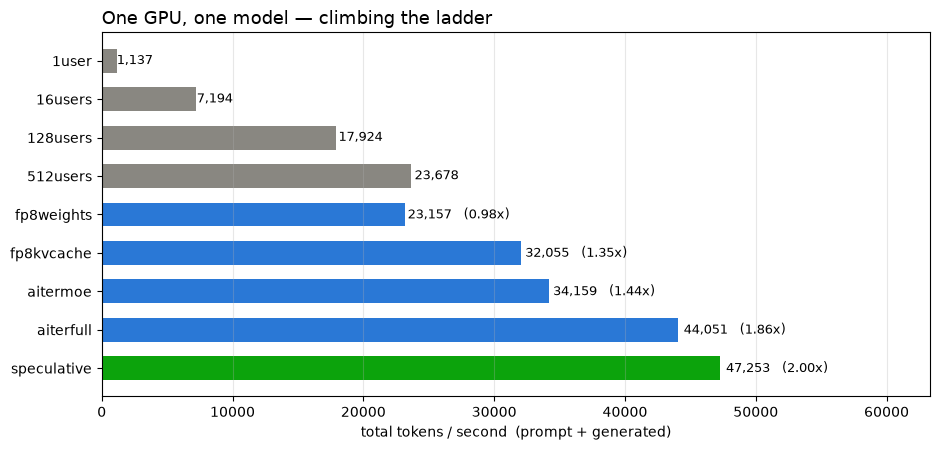

In [61]:
import matplotlib.pyplot as plt

names = [r[0] for r in rows]
vals  = [r[1] for r in rows]
ramp  = [n.endswith("user") or n.endswith("users") for n in names]

plt.figure(figsize=(9.5, 4.6))
colors = ["#898781" if r else "#2a78d6" for r in ramp]
colors[vals.index(max(vals))] = "#0ca30c"
bars = plt.barh(names, vals, color=colors, height=0.62)
base = next((v for n, v in zip(names, vals) if n.startswith("512users")), vals[0])
for i, v in enumerate(vals):
    plt.text(v * 1.01, i, f"{v:,.0f}" + ("" if ramp[i] else f"   ({v/base:.2f}x)"),
             va="center", fontsize=9)
plt.gca().invert_yaxis()
plt.xlim(0, max(vals) * 1.34)
plt.xlabel("total tokens / second  (prompt + generated)")
plt.title("One GPU, one model — climbing the ladder", loc="left", fontsize=13)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 📖 Reading the chart

**Grey bars** are the concurrency ramp — finding the right place to stand.
**Blue bars** are the optimisations, each measured at 128 users and compared to that grey 512-user bar.
**Green** is where we finished.

---

## 🧭 Four things to take home

**1. Benchmark at realistic concurrency.** One request tells you nothing about production.

**2. Read the startup log.** `Maximum concurrency` answers *"how many users can I serve?"* before you
write a single load test.

**3. KV cache is the ceiling.** Right-sizing, FP8 weights and FP8 cache are three ways of raising it.

**4. Change one thing, measure, repeat.** The only way to know *why* something got faster.

---

## 📋 Your production command

```bash
docker run -d --rm --name vllm-server \
    --network host --ipc host \
    --device /dev/kfd --device /dev/dri \
    --group-add video --group-add render \
    --shm-size 16g \
    -e HIP_VISIBLE_DEVICES=0 \
    -e VLLM_ROCM_USE_AITER=1 \
    -v ~/.cache/huggingface:/root/.cache/huggingface \
    --entrypoint '' \
    rocm/vllm:latest \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --port 8000 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
        --linear-backend aiter \
        --attention-backend ROCM_AITER_UNIFIED_ATTN \
        --speculative-config '{"method":"ngram","num_speculative_tokens":5,"prompt_lookup_max":4}' \
        --enable-auto-tool-choice --tool-call-parser hermes \
        --reasoning-parser qwen3
```

---
## 🔭 What we deliberately skipped

### 🚨 We never checked whether we broke anything

Two changes today were **lossy** — FP8 weights and, more so, the FP8 cache. Speculative decoding
isn't. Quantization is.

Before any of this reaches production: run an accuracy check across 16-bit → FP8 → FP8+FP8-cache and
decide whether the gap is acceptable **for your task**. A 2× speedup you can't defend on quality
isn't a speedup.

*This is the most important cell in the notebook, and it's the one we skipped for time.*

### 🖥️ Anything needing a second GPU

Tensor parallelism, expert parallelism (a natural fit for this MoE), data-parallel replicas,
prefill/decode disaggregation. That's the next talk.

### 🚦 Everything above a single server

We spent this hour making **one** model as fast as it goes. The next question is usually the opposite:
you have several models, and most requests don't need your biggest one.

[**vLLM Semantic Router**](https://github.com/vllm-project/semantic-router) classifies each incoming
request and picks which model should answer it. Trivial question → small fast model. Hard one → the
big reasoning model. Your app keeps calling one OpenAI-compatible endpoint and never knows.

It attacks a cost axis nothing today touched: every knob here made one model cheaper **per token**;
routing stops you spending the expensive model's tokens **at all**. On mixed traffic that's often the
bigger win — and the two stack.

### 📦 Also left out

Triton MoE autotuning · structured outputs (forcing valid JSON) · LoRA hot-swapping · and deliberately
starving the KV cache to watch requests get evicted — the fastest way to learn what a saturated vLLM
server looks like *before* you meet one at 3am.

In [62]:
# Free the GPU.
!docker logs vllm-server > logs/cpu-offload.log 2>&1; docker rm -f vllm-server

vllm-server


---
# 🎉 That's a wrap

You took a default `vllm serve` and climbed a ladder of flags to something several times faster,
on identical hardware.

More importantly, you now know **which questions to ask**:

> *What's my KV cache pool? How many users does that allow? Where on the throughput/latency curve do I
> want to sit? And did that flag actually take effect?*

**Go break something.** 🚀